In [341]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle as pkl
import re
import datetime as dt
import math

In [342]:
data = pd.read_csv('amazon_delivery.csv')

In [343]:
data.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [344]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [345]:
data.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [346]:
data['Order_ID'].duplicated().sum()

0

In [347]:
cols = list(data.columns)
ind = cols.index('Agent_Rating')
for index,row in data.iterrows():
    if np.isnan(row['Agent_Rating']):
        up_lim = row['Agent_Age']+5
        low_lim = row['Agent_Age']-5
        age_group_data = data[(data['Agent_Age']<up_lim) & (data['Agent_Age']>low_lim)]
        data.iloc[index,ind]=age_group_data['Agent_Rating'].mode()[0]

In [348]:
datatime_cols = ['Order_Date','Order_Time','Pickup_Time']

In [349]:
for col in datatime_cols:
    data[col] = data[col].str.strip(' ')
    data[col] = data[col].apply(lambda x:np.nan if re.match(r'[A-Za-z]',x) else x)


In [350]:
data['Order_Time'] = data['Order_Time'].fillna(data['Order_Time'].mode()[0])

In [351]:
data['Order_dt_time'] = data['Order_Date'] +' '+ data['Order_Time']

In [352]:
data['Order_dt_time'] = pd.to_datetime(data['Order_dt_time'])

In [353]:
cat_columns = [x for x in data.columns if data[x].dtype.name == 'object']

In [354]:
cat_columns

['Order_ID',
 'Order_Date',
 'Order_Time',
 'Pickup_Time',
 'Weather',
 'Traffic',
 'Vehicle',
 'Area',
 'Category']

In [355]:
for col in cat_columns:
    data[col] = data[col].str.strip(' ')
    data[col] = data[col].replace('NaN',np.nan)
    

In [356]:
data['Pickup_Time'] = pd.to_datetime(data['Pickup_Time'],format='%H:%M:%S')

In [357]:
data['Year'] = data['Order_dt_time'].dt.year
data['Month'] = data['Order_dt_time'].dt.month
data['Order_Day'] = data['Order_dt_time'].dt.day
data['Order_Dayofweek'] = data['Order_dt_time'].dt.dayofweek
data['Order_hour'] = data['Order_dt_time'].dt.hour

In [358]:
data['Pickup_hour'] = data['Pickup_Time'].dt.hour

In [359]:
data['Pickup_Day']=0
data['Pickup_Dayofweek']=0
for index,row in data.iterrows():
    if row['Pickup_hour']>=row['Order_hour']:
        data.iloc[index,-2] = row['Order_Day']
        data.iloc[index,-1] = row['Order_Dayofweek']
    elif row['Pickup_hour'] < row['Order_hour']:
        if row['Order_Day'] < 30:
            data.iloc[index,-2] = row['Order_Day']+1
        else:
            data.iloc[index,-2] = 1
        if row['Order_Dayofweek'] == 6:
            data.iloc[index,-1] = 0
        else:
            data.iloc[index,-1] = row['Order_Dayofweek']+1
    

In [360]:
ind_w = cols.index('Weather')
ind_t = cols.index('Traffic')
for index,row in data.iterrows():
    if row['Weather'] is np.nan or row['Traffic'] is np.nan:
        group_data = data[(data['Area']==row['Area']) & (data['Order_Date']==row['Order_Date'])]
        if row['Weather'] is np.nan:
            data.iloc[index,ind_w] = group_data['Weather'].mode()[0]
        if row['Traffic'] is np.nan:
            data.iloc[index,ind_t] = group_data['Traffic'].mode()[0]


In [361]:
data.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating        0
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather             0
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
Order_dt_time       0
Year                0
Month               0
Order_Day           0
Order_Dayofweek     0
Order_hour          0
Pickup_hour         0
Pickup_Day          0
Pickup_Dayofweek    0
dtype: int64

In [362]:
def dist(lat1,lon1,lat2,lon2):
    phi1 = math.radians(abs(lat1))
    phi2 = math.radians(abs(lat2))
    del_phi = math.radians(abs(lat2)-abs(lat1))
    del_lam = math.radians(abs(lon2)-abs(lon1))
    r = 6371
    a = (math.sin(del_phi/2)**2)+((math.cos(phi1))*(math.cos(phi2))*((math.sin(del_lam/2))**2))
    distance = 2*r*(math.asin(math.sqrt(a)))
    distance = round(distance,4)
    return distance


In [363]:
data['Distance'] = float(0)
for index,row in data.iterrows():
    slat = row['Store_Latitude']
    slon = row['Store_Longitude']
    dlat = row['Drop_Latitude']
    dlon = row['Drop_Longitude']
    data.iloc[index,-1] = dist(slat,slon,dlat,dlon)

In [364]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          43739 non-null  object        
 1   Agent_Age         43739 non-null  int64         
 2   Agent_Rating      43739 non-null  float64       
 3   Store_Latitude    43739 non-null  float64       
 4   Store_Longitude   43739 non-null  float64       
 5   Drop_Latitude     43739 non-null  float64       
 6   Drop_Longitude    43739 non-null  float64       
 7   Order_Date        43739 non-null  object        
 8   Order_Time        43739 non-null  object        
 9   Pickup_Time       43739 non-null  datetime64[ns]
 10  Weather           43739 non-null  object        
 11  Traffic           43739 non-null  object        
 12  Vehicle           43739 non-null  object        
 13  Area              43739 non-null  object        
 14  Delivery_Time     4373

In [365]:
req_cols = ['Agent_Age','Agent_Rating','Weather','Traffic','Vehicle','Area','Category','Year','Month','Order_Day',
            'Order_Dayofweek','Order_hour','Pickup_Day','Pickup_Dayofweek','Pickup_hour','Distance','Delivery_Time']

In [366]:
delivery_df = data[req_cols]

In [367]:
delivery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Agent_Age         43739 non-null  int64  
 1   Agent_Rating      43739 non-null  float64
 2   Weather           43739 non-null  object 
 3   Traffic           43739 non-null  object 
 4   Vehicle           43739 non-null  object 
 5   Area              43739 non-null  object 
 6   Category          43739 non-null  object 
 7   Year              43739 non-null  int32  
 8   Month             43739 non-null  int32  
 9   Order_Day         43739 non-null  int32  
 10  Order_Dayofweek   43739 non-null  int32  
 11  Order_hour        43739 non-null  int32  
 12  Pickup_Day        43739 non-null  int64  
 13  Pickup_Dayofweek  43739 non-null  int64  
 14  Pickup_hour       43739 non-null  int32  
 15  Distance          43739 non-null  float64
 16  Delivery_Time     43739 non-null  int64 

In [368]:
delivery_df.describe()

,Agent_Age,Agent_Rating,Year,Month,Order_Day,Order_Dayofweek,Order_hour,Pickup_Day,Pickup_Dayofweek,Pickup_hour,Distance,Delivery_Time
count,43739.000000,43739.000000,43739.0,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633915,2022.0,2.979812,13.812341,3.000800,17.433412,13.803333,2.997554,17.153159,9.732784,124.905645
std,5.815155,0.334537,0.0,0.546506,8.706032,1.969838,4.816232,8.698422,1.970301,5.320014,5.603678,51.915451
min,15.000000,1.000000,2022.0,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.465100,10.000000
25%,25.000000,4.500000,2022.0,3.000000,6.000000,1.000000,15.000000,6.000000,1.000000,14.000000,4.663400,90.000000
50%,30.000000,4.700000,2022.0,3.000000,13.000000,3.000000,19.000000,13.000000,3.000000,19.000000,9.220100,125.000000
75%,35.000000,4.900000,2022.0,3.000000,20.000000,5.000000,21.000000,20.000000,5.000000,21.000000,13.681400,160.000000
max,50.000000,6.000000,2022.0,4.000000,31.000000,6.000000,23.000000,31.000000,6.000000,23.000000,20.969500,270.000000


In [369]:
cols = delivery_df.columns.to_list()

In [370]:
cat_columns = [x for x in cols if delivery_df[x].dtype.name == 'object']
num_cols = [x for x in cols if delivery_df[x].dtype.name != 'object']

In [371]:
for col in num_cols:
    if len(delivery_df[col].unique())<=5:
        print(col)

Year
Month


In [372]:
print(delivery_df['Year'].unique())
print(delivery_df['Month'].unique())

[2022]
[3 4 2]


In [373]:
delivery_df=delivery_df.drop('Year',axis=1)

In [374]:
cat_columns.append('Month')
num_cols.remove('Month')
num_cols.remove('Year')

In [375]:
for col in num_cols:
    if len(delivery_df[col].unique())<=7:
        cat_columns.append(col)

In [376]:
sns.set_theme(context='talk',style='darkgrid',palette='deep')

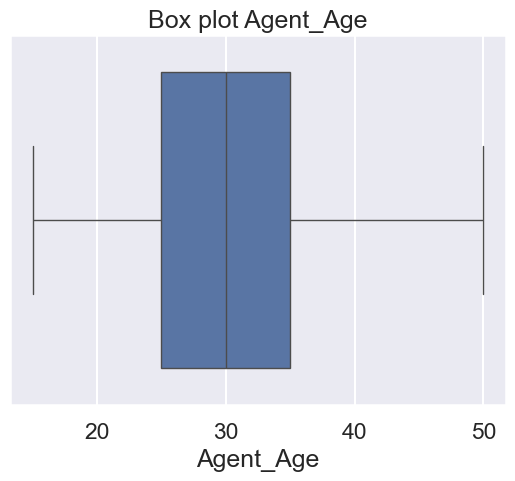

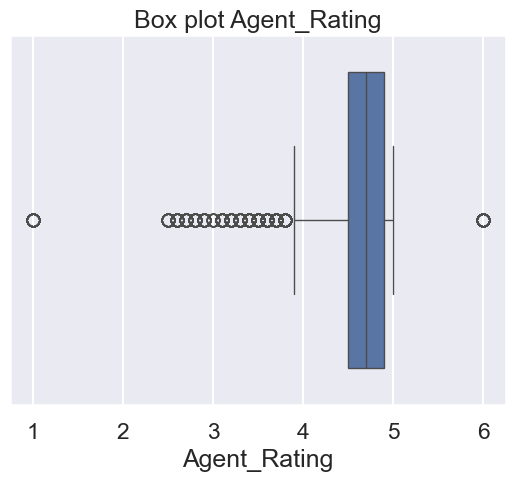

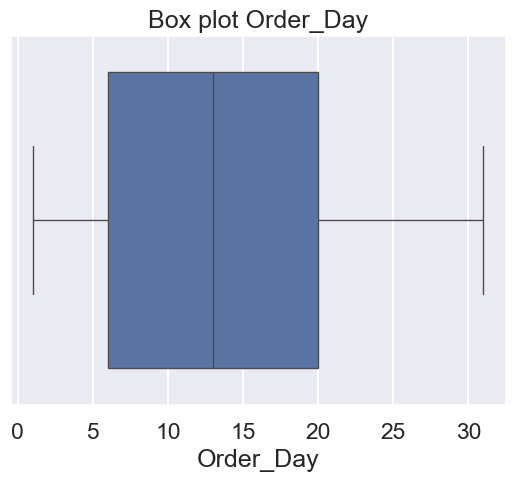

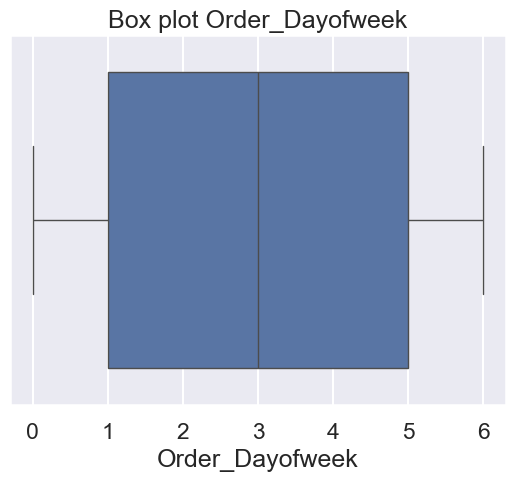

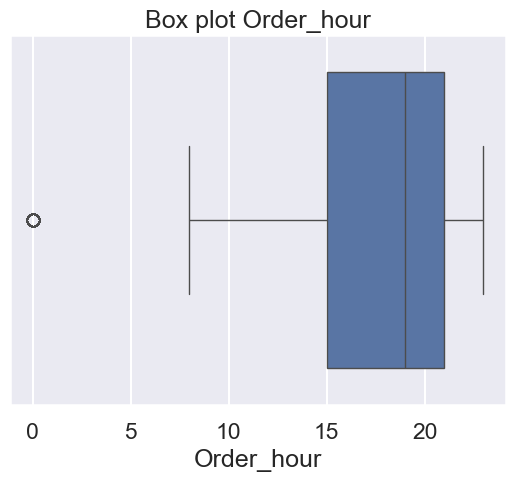

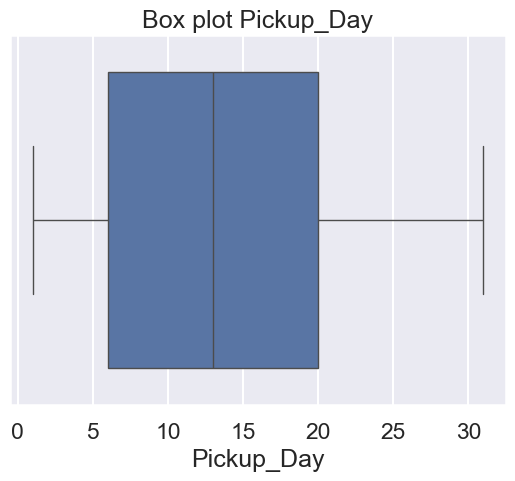

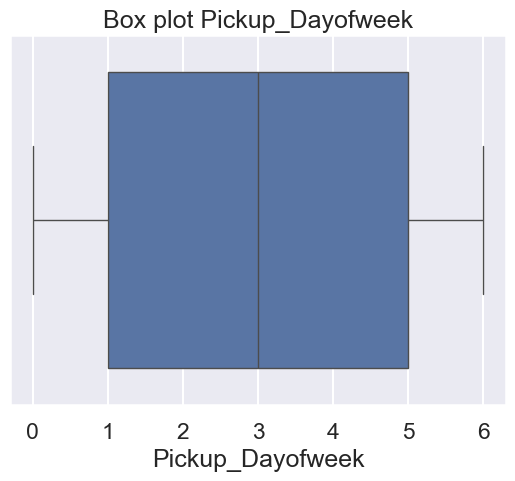

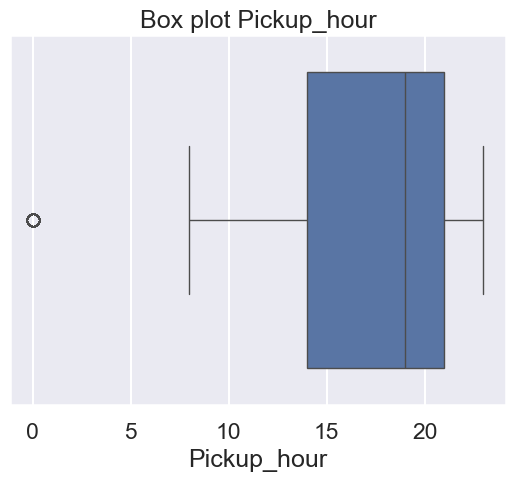

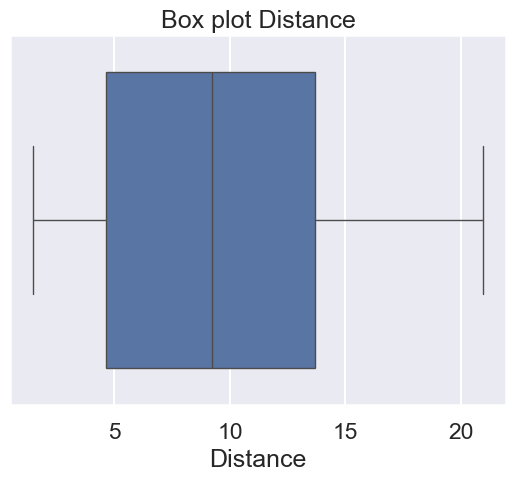

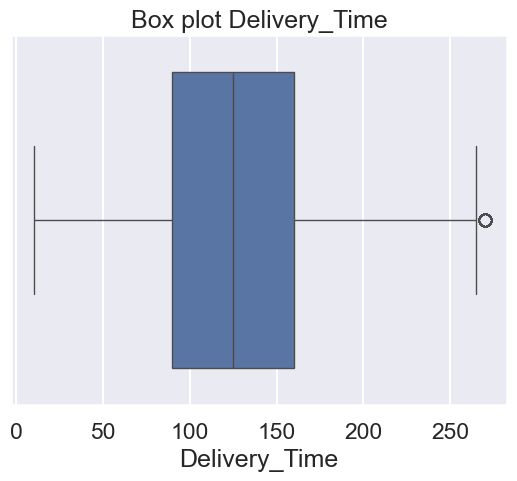

In [377]:
for col in num_cols:
    sns.boxplot(data=delivery_df,x=col)
    plt.title(f'Box plot {col}')
    plt.show()

In [378]:
delivery_df['Agent_Rating'] = [x-1 if x == 6 else x for x in delivery_df['Agent_Rating']]


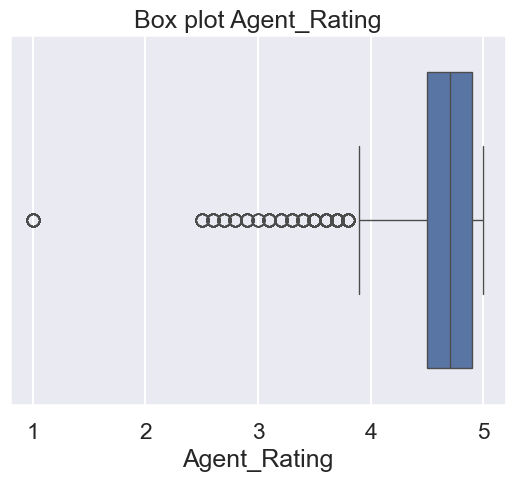

In [379]:
sns.boxplot(data=delivery_df,x='Agent_Rating')
plt.title(f'Box plot Agent_Rating')
plt.show()

Text(0.5, 1.0, 'Distribution of Target')

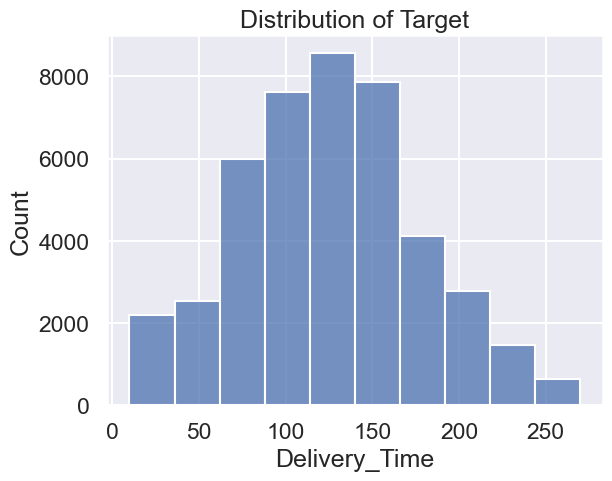

In [380]:
sns.histplot(data=delivery_df,bins=10,x='Delivery_Time')
plt.title('Distribution of Target')

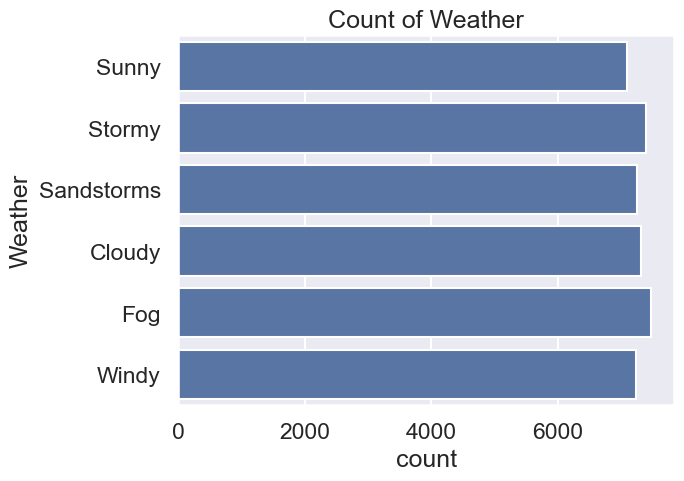

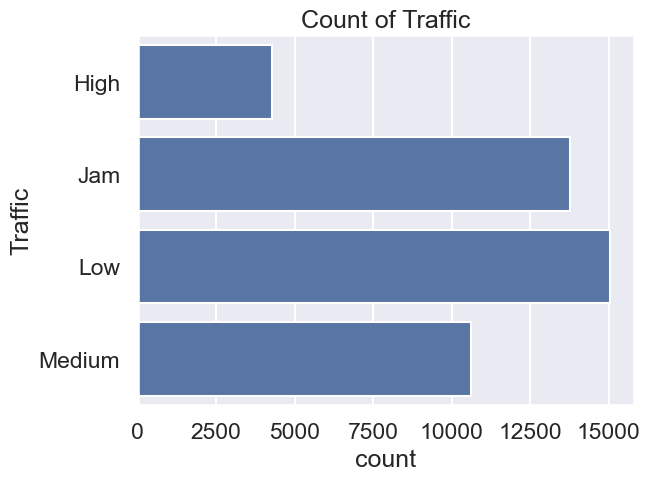

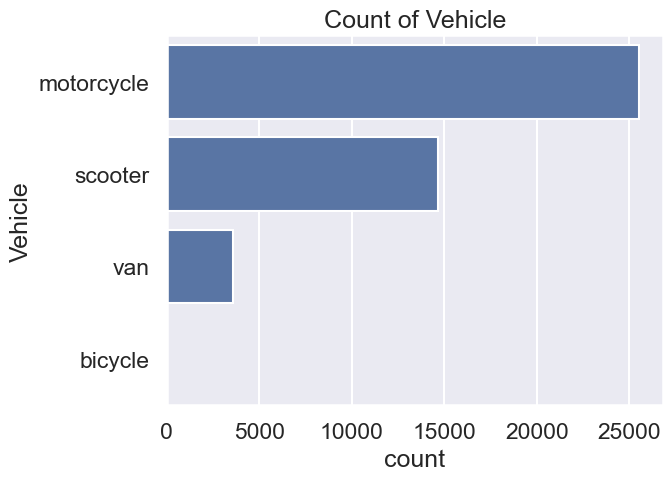

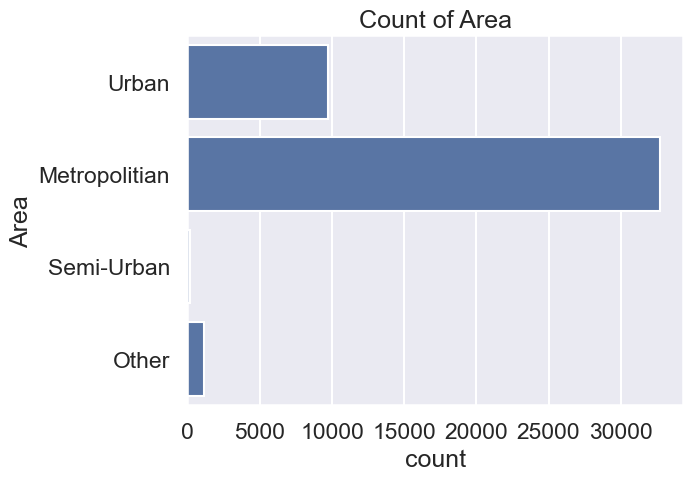

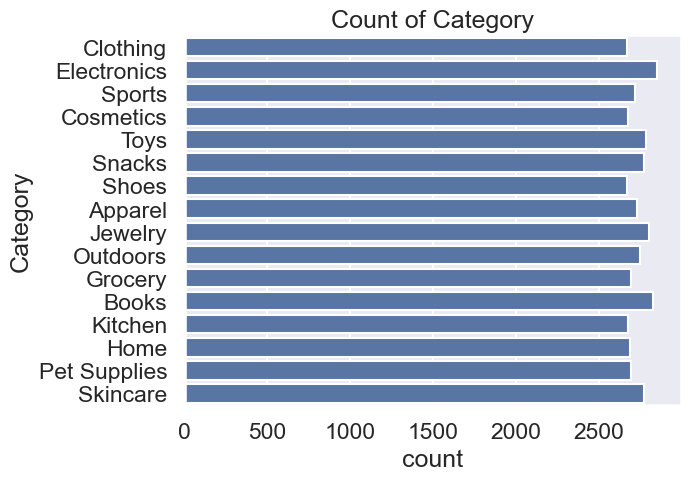

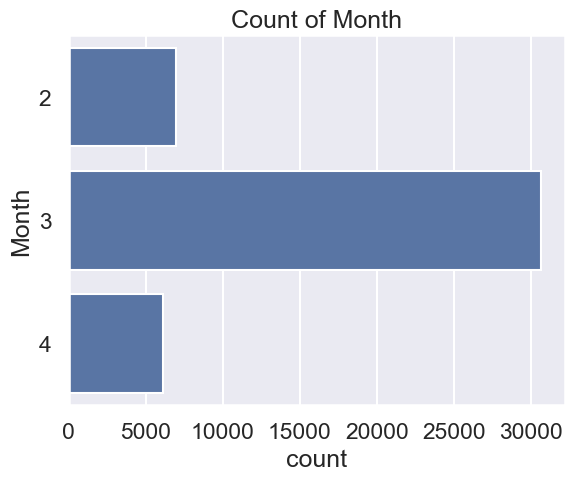

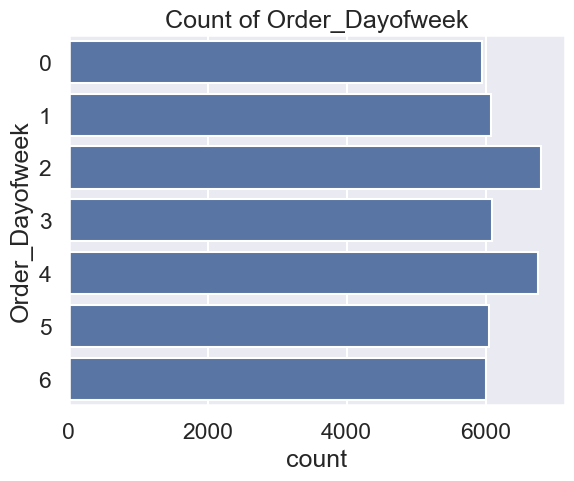

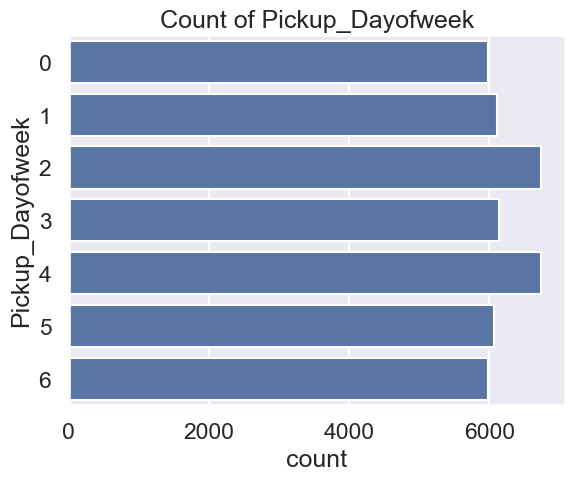

In [381]:
for col in cat_columns:
    sns.countplot(data=delivery_df,y=col)
    plt.title(f'Count of {col}')
    plt.show()

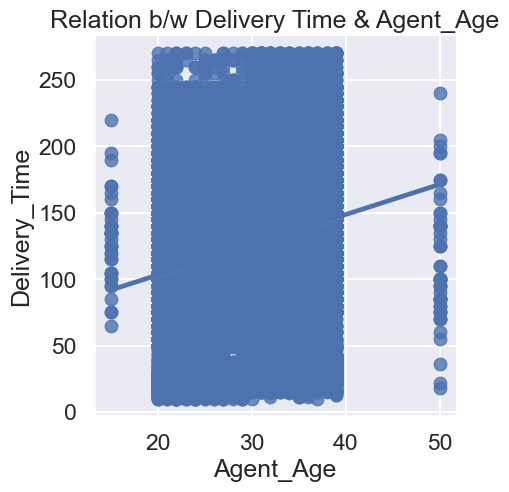

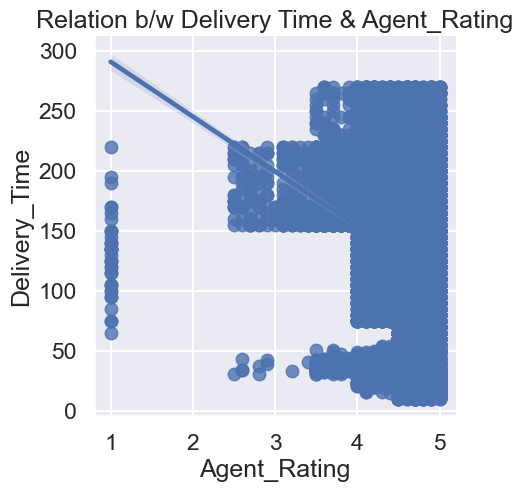

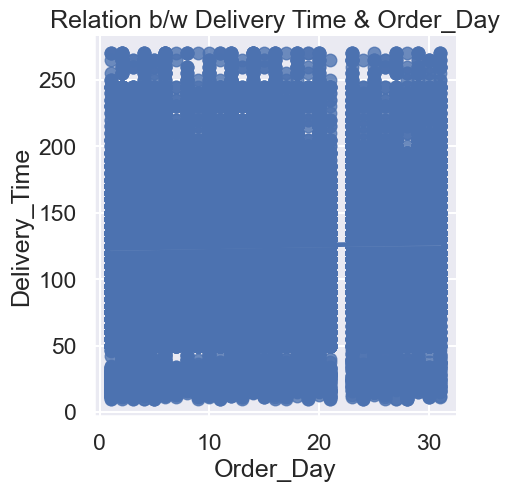

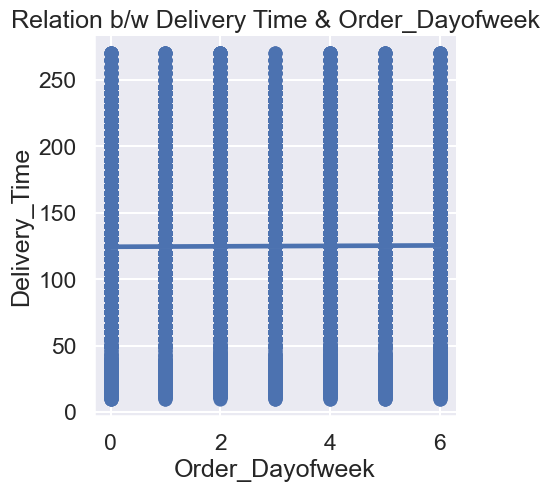

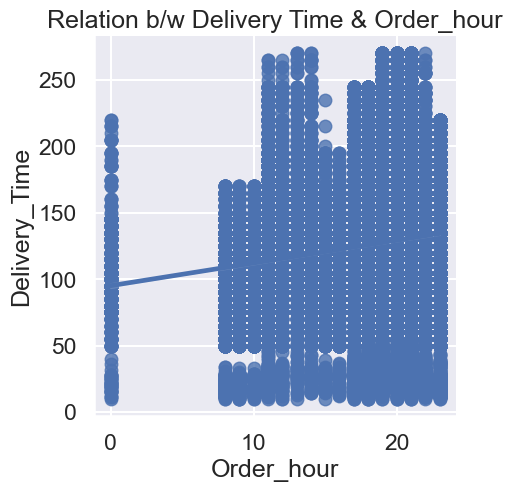

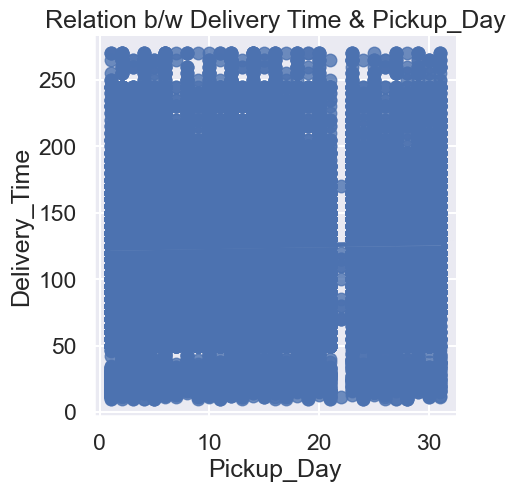

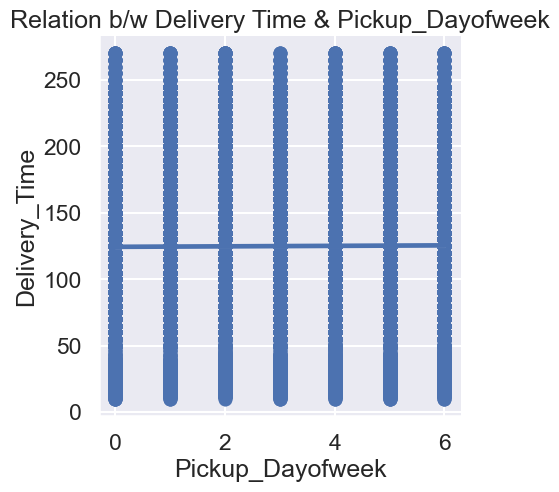

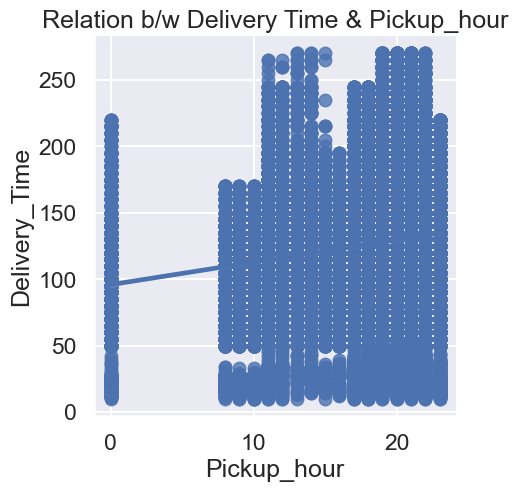

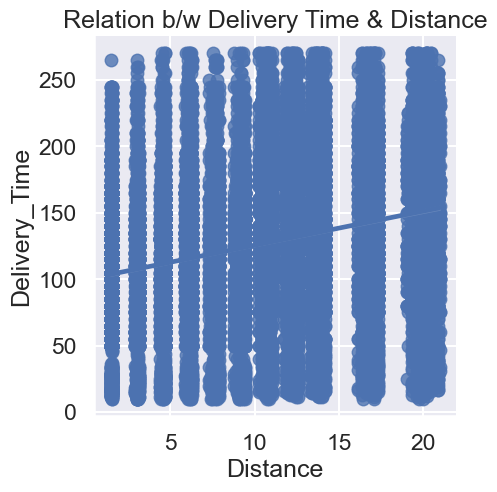

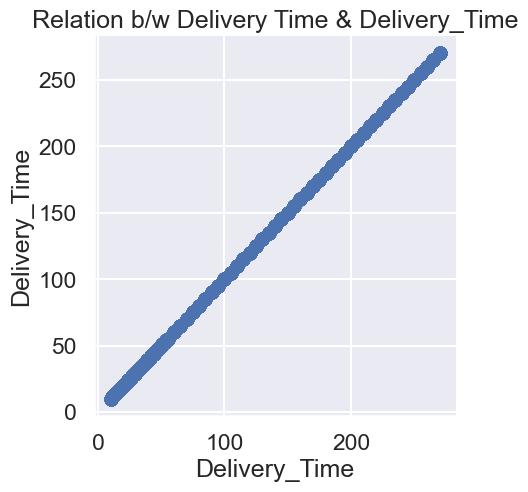

In [382]:
for col in num_cols:
    sns.lmplot(delivery_df,x=col,y='Delivery_Time')
    plt.title(f'Relation b/w Delivery Time & {col}')
    plt.show()

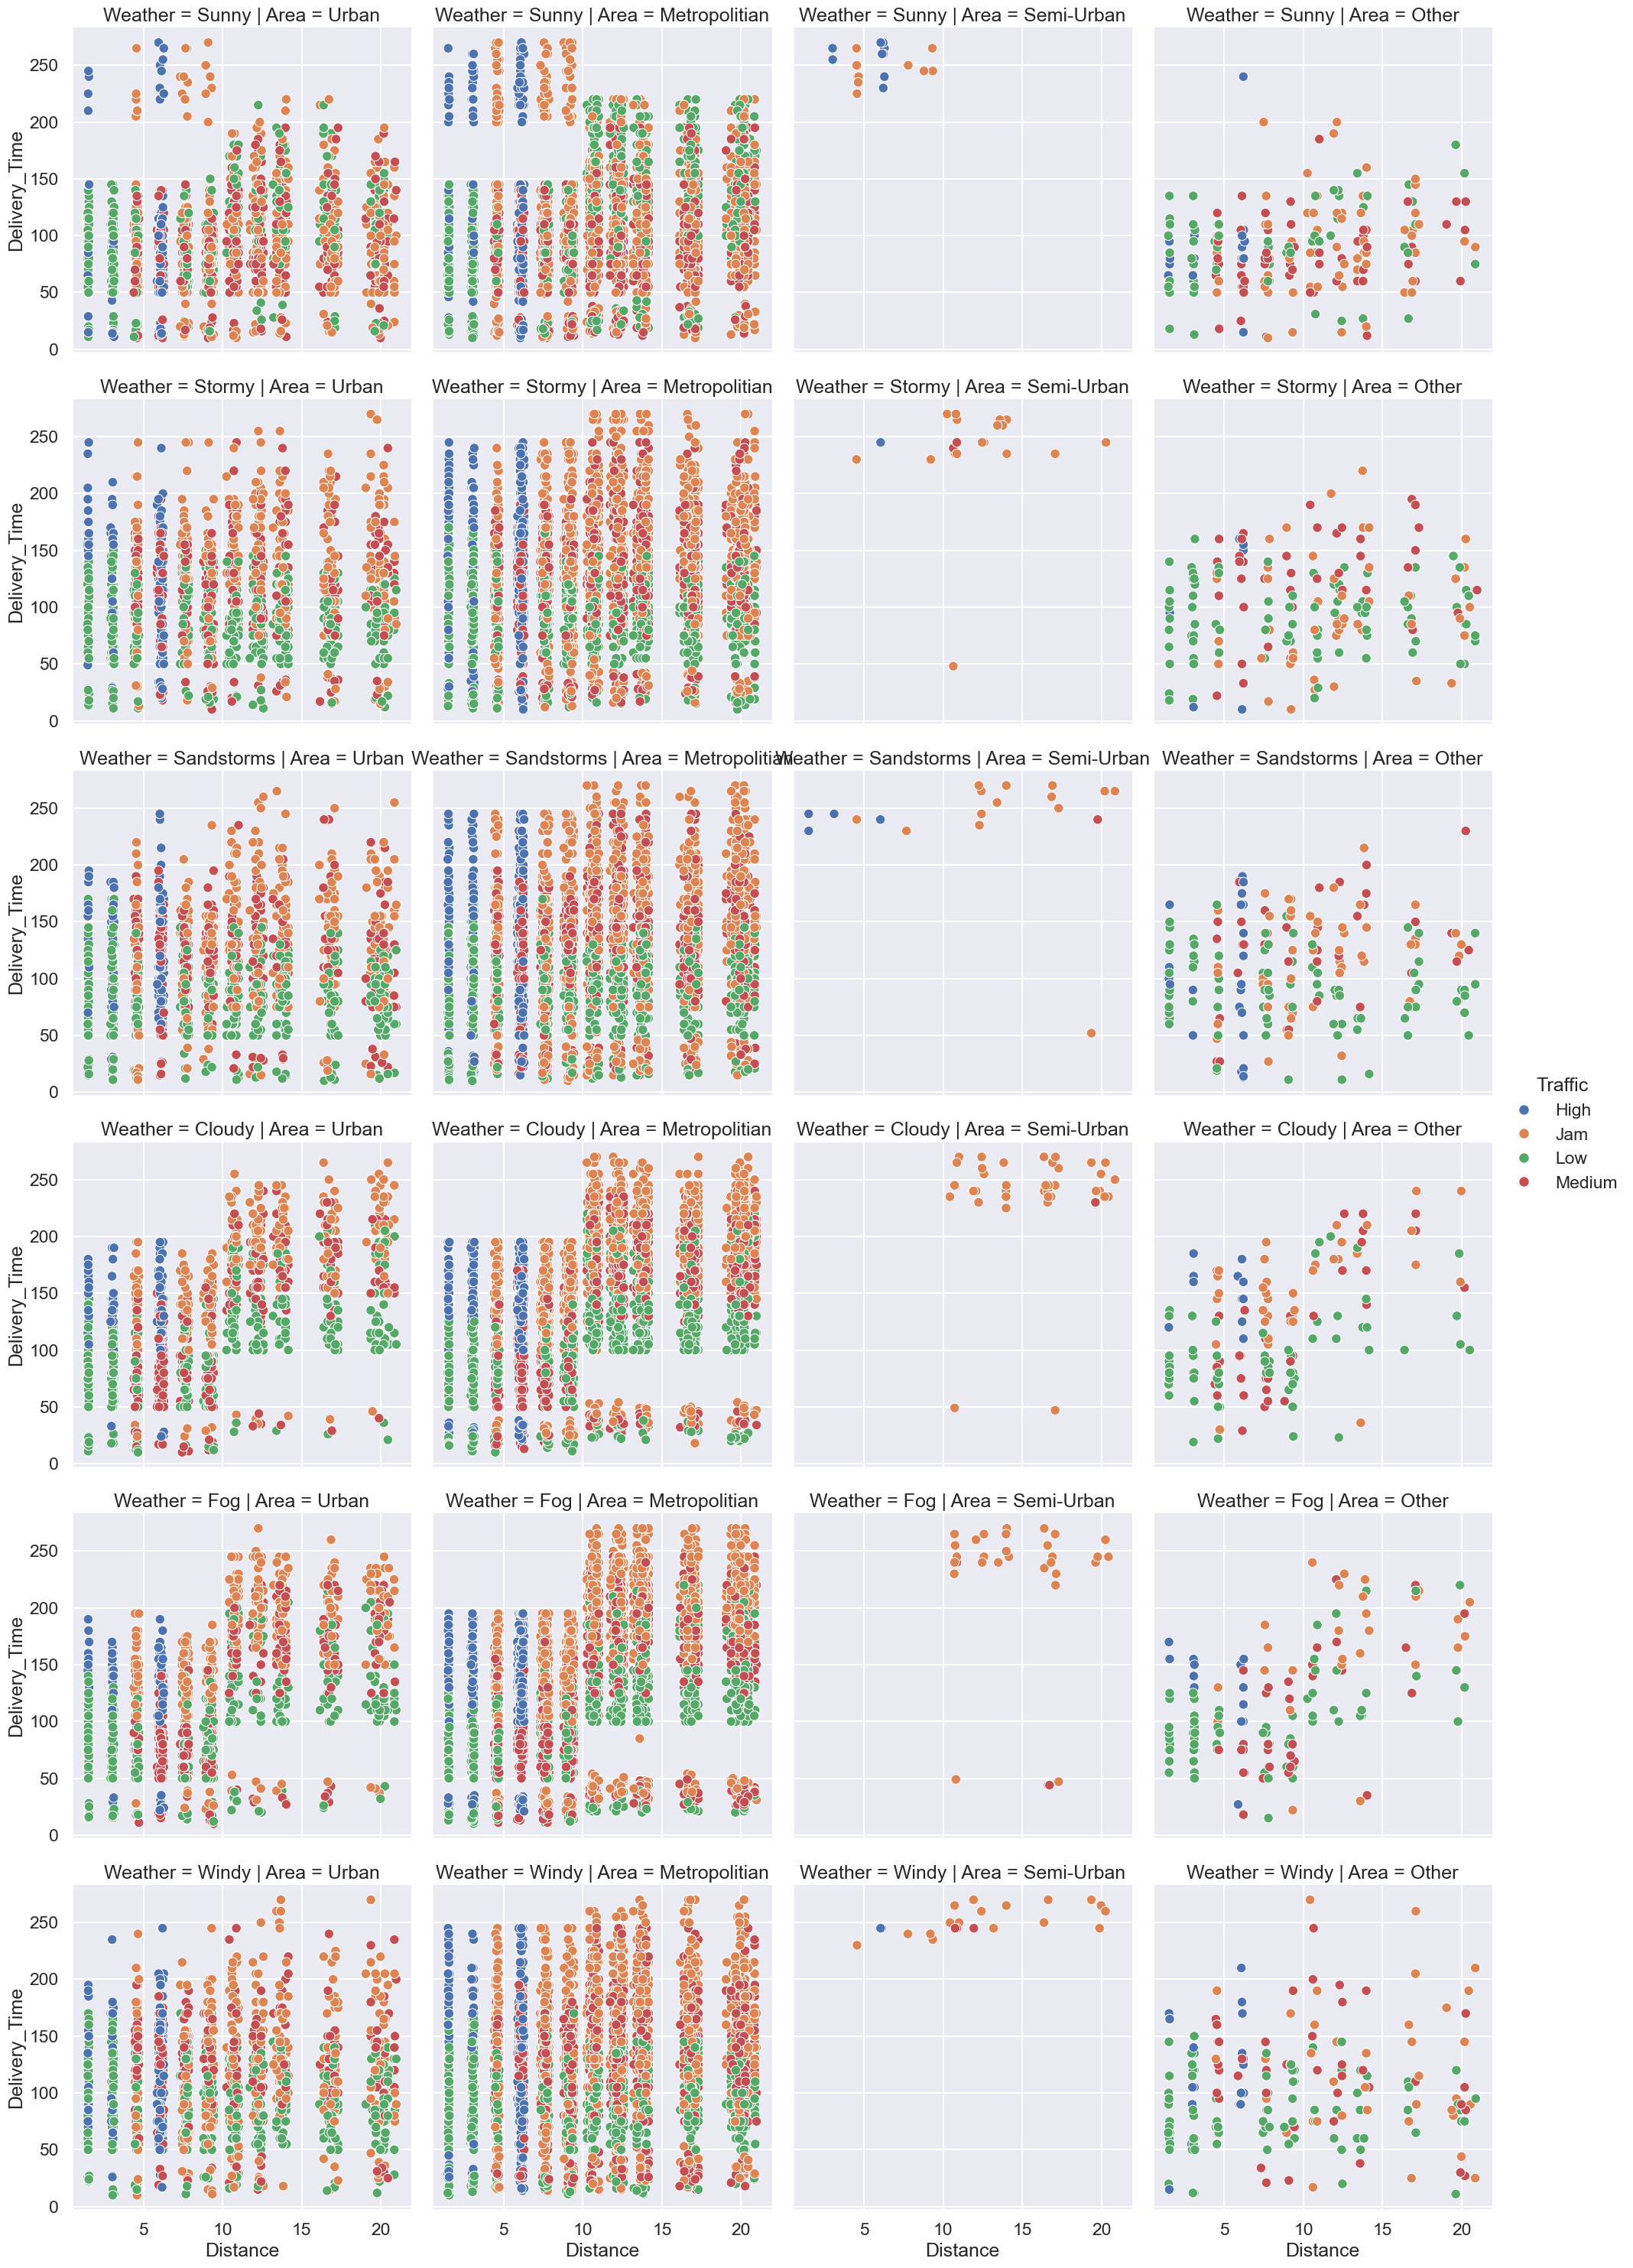

In [383]:
sns.relplot(delivery_df,x='Distance',y='Delivery_Time',kind='scatter',col='Area',hue='Traffic',row='Weather')
plt.xlabel('Distance')
plt.show()

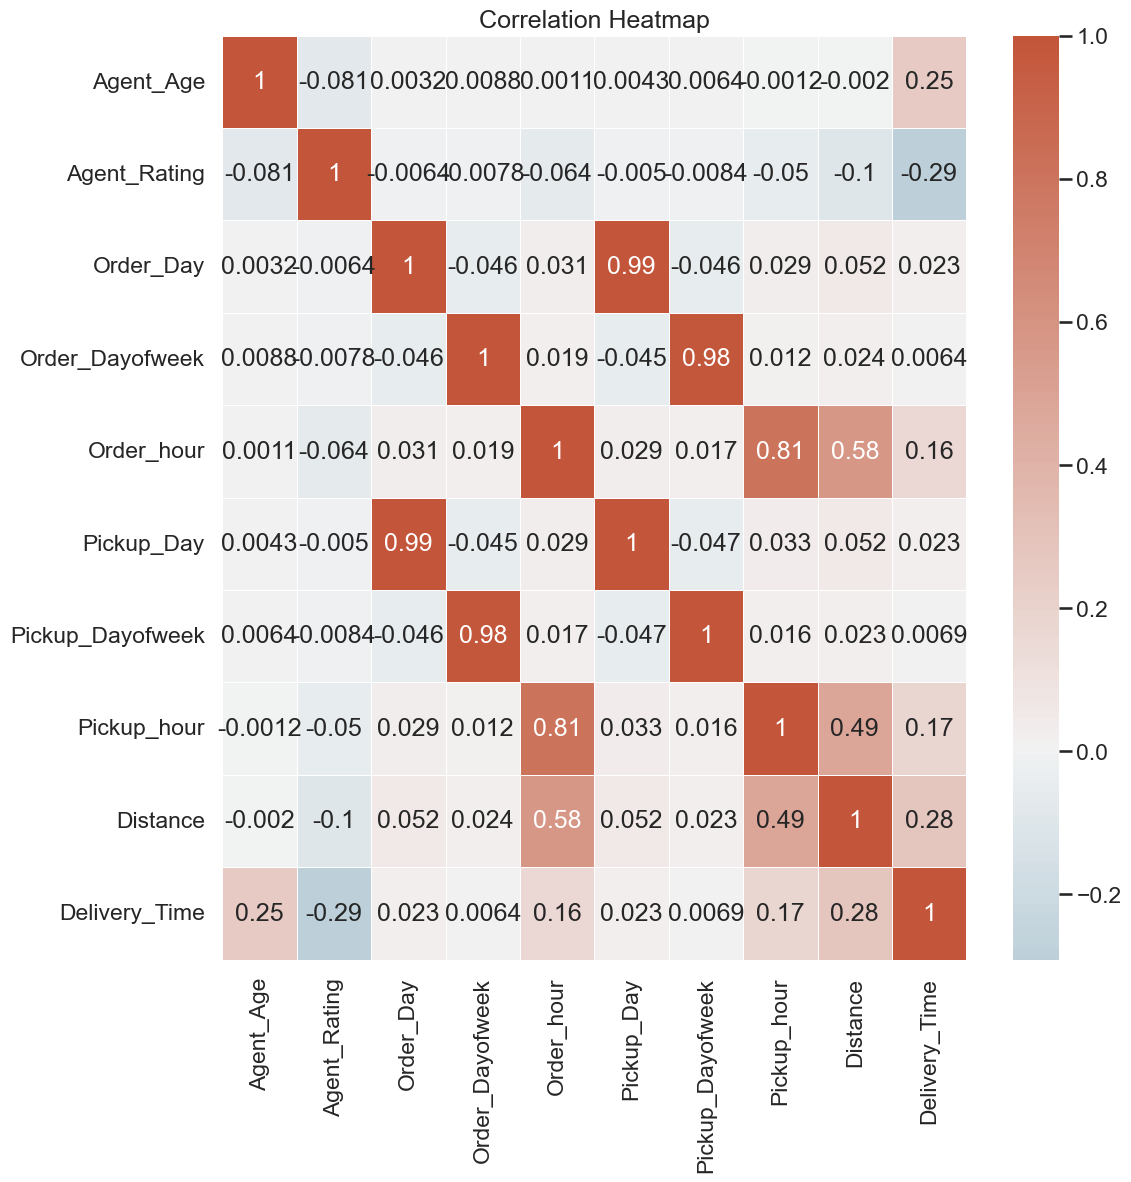

In [384]:
corr_df = delivery_df[num_cols]
corr_mat = corr_df.corr()
f, ax = plt.subplots(figsize=(12, 12))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_mat,linewidths=0.5,linecolor='white',center=0,annot=True,cmap=cmap)
plt.title('Correlation Heatmap')
plt.show()

In [385]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
import mlflow

In [386]:
def regression_report(yt,yp):
    report = {'mae':mean_absolute_error(yt,yp).round(2),
              'rmse':root_mean_squared_error(yt,yp).round(2),
              'r2':(r2_score(yt,yp)).__round__(4)}
    return report

In [387]:
print(delivery_df.head())

   Agent_Age  Agent_Rating     Weather Traffic     Vehicle           Area  \
0         37           4.9       Sunny    High  motorcycle          Urban   
1         34           4.5      Stormy     Jam     scooter  Metropolitian   
2         23           4.4  Sandstorms     Low  motorcycle          Urban   
3         38           4.7       Sunny  Medium  motorcycle  Metropolitian   
4         32           4.6      Cloudy    High     scooter  Metropolitian   

      Category  Month  Order_Day  Order_Dayofweek  Order_hour  Pickup_Day  \
0     Clothing      3         19                5          11          19   
1  Electronics      3         25                4          19          25   
2       Sports      3         19                5           8          19   
3    Cosmetics      4          5                1          18           5   
4         Toys      3         26                5          13          26   

   Pickup_Dayofweek  Pickup_hour  Distance  Delivery_Time  
0             

In [388]:
ordinal_cols = ['Traffic','Area']
ohe_cols = ['Weather','Category','Vehicle']
num_cols=['Agent_Age','Agent_Rating','Distance']
y_col = 'Delivery_Time'
x_cols = list(delivery_df.columns)
x_cols.remove(y_col)

In [398]:
delivery_df['Category'].unique()

array(['Clothing', 'Electronics', 'Sports', 'Cosmetics', 'Toys', 'Snacks',
       'Shoes', 'Apparel', 'Jewelry', 'Outdoors', 'Grocery', 'Books',
       'Kitchen', 'Home', 'Pet Supplies', 'Skincare'], dtype=object)

In [390]:
order_traffic = ['Low','Medium','High','Jam']
order_area = ['Other','Semi-Urban','Urban','Metropolitian']
ordinal_order = [order_traffic,order_area]

In [391]:
preprocessor = ColumnTransformer(transformers=[('ordinal',OrdinalEncoder(categories=ordinal_order),ordinal_cols),
                                               ('label',OneHotEncoder(),ohe_cols),
                                               ('norm',StandardScaler(),num_cols)])

In [392]:
X = delivery_df[x_cols]
y = delivery_df[y_col]

In [393]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=10)

In [ ]:
xtest.to_csv('Test_data.csv',index=False)

In [ ]:
models = [('DecisionTree',DecisionTreeRegressor),('RandomForest',RandomForestRegressor),('GradientBoost',GradientBoostingRegressor),('XGBoost',XGBRegressor),
          ('AdaBoost',AdaBoostRegressor),('KNNeighbour',KNeighborsRegressor),('SupportVector',SVR)]

In [320]:
parameters={'DecisionTree':[{'criterion':'friedman_mse','max_depth':50,'min_samples_split':5,'min_samples_leaf':4},{'criterion':'friedman_mse','max_depth':100,'min_samples_split':5,'min_samples_leaf':4},
                            {'criterion':'friedman_mse','max_depth':100,'min_samples_split':10,'min_samples_leaf':4}],
            'RandomForest':[{"criterion":'poisson',"n_estimators":100,'max_depth':50},{"criterion":'poisson',"n_estimators":200,'max_depth':50},{"criterion":'friedman_mse',"n_estimators":200,'max_depth':50}],
            'GradientBoost':[{'n_estimators':100,'learning_rate':0.1,'alpha':0.9},{'n_estimators':100,'learning_rate':0.01,'alpha':0.5},{'n_estimators':100,'learning_rate':0.01,'alpha':0.1},
                             {'n_estimators':500,'learning_rate':0.1,'alpha':0.9},{'n_estimators':500,'learning_rate':0.01,'alpha':0.5},{'n_estimators':500,'learning_rate':0.01,'alpha':0.1},
                             {'n_estimators':1000,'learning_rate':0.1,'alpha':0.9},{'n_estimators':1000,'learning_rate':0.01,'alpha':0.5},{'n_estimators':1000,'learning_rate':0.01,'alpha':0.1}],
            'XGBoost':[{'max_depth':5,'eta':0.1,'subsample':0.5,'colsample_bytree':0.5},{'max_depth':8,'eta':0.05,'subsample':1,'colsample_bytree':0.9},{'max_depth':8,'eta':0.05,'subsample':0.5,'colsample_bytree':0.9}],
            'AdaBoost':[{'n_estimators':100,'learning_rate':0.1,'loss':'linear'},{'n_estimators':500,'learning_rate':0.1,'loss':'linear'},{'n_estimators':1000,'learning_rate':0.1,'loss':'linear'},
                        {'n_estimators':100,'learning_rate':0.01,'loss':'linear'},{'n_estimators':500,'learning_rate':0.01,'loss':'linear'},{'n_estimators':1000,'learning_rate':0.01,'loss':'linear'},
                        {'n_estimators':100,'learning_rate':0.1,'loss':'square'},{'n_estimators':500,'learning_rate':0.1,'loss':'square'},{'n_estimators':1000,'learning_rate':0.1,'loss':'square'},
                        {'n_estimators':100,'learning_rate':0.01,'loss':'square'},{'n_estimators':500,'learning_rate':0.01,'loss':'square'},{'n_estimators':1000,'learning_rate':0.01,'loss':'square'},
                        {'n_estimators':100,'learning_rate':0.1,'loss':'exponential'},{'n_estimators':500,'learning_rate':0.1,'loss':'exponential'},{'n_estimators':1000,'learning_rate':0.1,'loss':'exponential'},
                        {'n_estimators':100,'learning_rate':0.01,'loss':'exponential'},{'n_estimators':500,'learning_rate':0.01,'loss':'exponential'},{'n_estimators':1000,'learning_rate':0.01,'loss':'exponential'}],
            'KNNeighbour':[{'n_neighbors':5,'weights':'uniform','p':2},{'n_neighbors':10,'weights':'uniform','p':2},{'n_neighbors':20,'weights':'uniform','p':2},{'n_neighbors':50,'weights':'uniform','p':2},
                           {'n_neighbors':5,'weights':'distance','p':2},{'n_neighbors':10,'weights':'distance','p':2},{'n_neighbors':20,'weights':'distance','p':2},{'n_neighbors':50,'weights':'distance','p':2}],
            'SupportVector':[{"kernel":'rbf','degree':3,'C':1.5,'epsilon':0.1,'tol':0.001,'cache_size':200},{"kernel":'rbf','degree':5,'C':1.5,'epsilon':0.1,'tol':0.001,'cache_size':200},{"kernel":'rbf','degree':7,'C':1.5,'epsilon':0.1,'tol':0.001,'cache_size':200},
                             {"kernel":'rbf','degree':3,'C':0.1,'epsilon':0.1,'tol':0.001,'cache_size':200},{"kernel":'rbf','degree':5,'C':0.1,'epsilon':0.1,'tol':0.001,'cache_size':200},{"kernel":'rbf','degree':7,'C':0.1,'epsilon':0.1,'tol':0.001,'cache_size':200}]}

In [322]:
mlflow.set_experiment('Amazon Delivery')
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")
for x in models:
        model_name = x[0]
        model = x[1]
        for i,param in enumerate(parameters[model_name]):
            pipe = Pipeline(steps=[('preprocess',preprocessor),('regressor',model(**param))])
            with mlflow.start_run(run_name=f'{model_name}{i}'):
                pipe.fit(xtrain,ytrain)
                y_pred = pipe.predict(xtest)
                report = regression_report(ytest,y_pred)
                mlflow.sklearn.log_model(pipe,f'{model_name}{i}')
                mlflow.log_params(param)
                mlflow.log_metric('MAE',report['mae'])
                mlflow.log_metric('RMSE',report['rmse'])
                mlflow.log_metric('R2_Score',report['r2'])


2025/07/24 14:46:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/24 14:46:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run DecisionTree0 at: http://127.0.0.1:5000/#/experiments/546613106588887236/runs/4421bd01445d436b8ffa8af9a210919c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546613106588887236


2025/07/24 14:46:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/24 14:46:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run DecisionTree1 at: http://127.0.0.1:5000/#/experiments/546613106588887236/runs/335e1ce05b0f4429b59558e8b5ec37d3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546613106588887236


2025/07/24 14:46:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/24 14:47:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

🏃 View run SupportVector3 at: http://127.0.0.1:5000/#/experiments/546613106588887236/runs/02a56c321ab44373a52cf07bedaf5141
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546613106588887236


2025/07/24 15:22:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/24 15:22:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run SupportVector4 at: http://127.0.0.1:5000/#/experiments/546613106588887236/runs/78c886bbee554b8e81c1fe42e1030d39
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546613106588887236


2025/07/24 15:23:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/24 15:23:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run SupportVector5 at: http://127.0.0.1:5000/#/experiments/546613106588887236/runs/5546f8c3e75e4d55b7c2b831656460b7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/546613106588887236


In [395]:
sample_df = xtest[:1]
pkl.dump(sample_df,open('ipex.sav','wb'))